# 학습 목표
- Iceberg 히든 파티셔닝의 개념을 파악하고 실습을 통해 명확히 이해한다.

---

# 참고 문서
- Apache Iceberg hidden partition: https://iceberg.apache.org/spec/#partition-transforms
- Apache Iceberg partition transforms: https://iceberg.apache.org/spec/#partition-transforms
- Apache Iceberg partition evolution: https://iceberg.apache.org/docs/1.10.0/docs/evolution/#partition-evolution

---

# What is hidden partition of Iceberg?
- Iceberg의 Hidden Partition은 사용자가 쿼리할 때 파티션 컬럼을 직접 의식하지 않아도, Iceberg가 쿼리 플래닝 단계에서 자동으로 파티셔닝을 적용하는 것을 의미한다.
- 즉, 테이블 스키마에 존재하는 컬럼을 그대로 노출하지 않고도 내부적으로 변환된 파티션 키를 생성하여 관리한다.
- 예를 들어 PARTITIONED BY (days(ts))라고 정의하면, 사용자는 단순히 WHERE ts = '2025-10-07'라고만 쿼리하면 되고, Iceberg가 내부적으로 ts_day라는 숨겨진 파티션 컬럼을 사용해 최적화된 데이터 스캔을 수행한다.

# Why hidden partition? 🤔
- 사용자 편의성: 쿼리할 때 파티션 컬럼을 몰라도 되며, 원래 컬럼 그대로 사용할 수 있다.
- 쿼리 최적화: 숨겨진 파티션 컬럼을 활용해 불필요한 데이터 스캔을 줄이고 성능을 향상시킨다.
- 스키마 단순성: 테이블 정의에서 파티션 컬럼을 따로 노출하지 않으므로 스키마가 깔끔하게 유지된다.
- **유연성**: 파티션 전략을 변경해도 기존 쿼리 로직에는 영향을 주지 않고 하위 호환성을 보장한다.

---

In [1]:
# !python3 -m pip install boto3

In [2]:
import json
from IPython.display import Image
from utils.iceberg_metadata_properties import IcebergMetadataJsonField, FIELD_DESCRIPTIONS
from utils.get_iceberg_metadata import get_metadata
from pyspark.sql.functions import input_file_name

---

# Hidden partition 사용하기

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
        .appName("IcebergSparkWithMinIo") \
        .config("spark.sql.catalog.my_catalog", "org.apache.iceberg.spark.SparkCatalog") \
        .config("spark.sql.catalog.my_catalog.type", "rest") \
        .config("spark.sql.catalog.my_catalog.uri", "http://iceberg-rest:8181") \
        .config("spark.sql.catalog.my_catalog.warehouse", "s3a://warehouse/") \
        .config("spark.sql.catalog.my_catalog.io-impl", "org.apache.iceberg.aws.s3.S3FileIO") \
        .config("spark.sql.catalog.my_catalog.s3.endpoint", "http://minio:9000") \
        .config("spark.sql.catalog.my_catalog.s3.access-key-id", "admin") \
        .config("spark.sql.catalog.my_catalog.s3.secret-access-key", "password") \
        .config("spark.sql.catalog.my_catalog.s3.path-style-access", "true") \
        .config("spark.sql.extensions", "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions") \
        .getOrCreate()

25/10/09 15:49:04 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


- 아래 DDL 처럼 DATE 타입의 sale_date 컬럼을 month 함수로 변환시킨 값을 기준으로 파티셔닝을 지정할 수 있다.
- [Iceberg Prtition transforms](https://iceberg.apache.org/spec/#partition-transforms)

In [4]:
spark.sql("""
CREATE DATABASE IF NOT EXISTS my_catalog.my_database
""")
spark.sql("""
CREATE TABLE IF NOT EXISTS my_catalog.my_database.sales (
    id BIGINT,
    item STRING,
    category STRING,
    sale_date DATE
)
USING ICEBERG
PARTITIONED BY (month(sale_date))
""")

DataFrame[]

- 아래와 같이 데이터를 삽입하면 Iceberg 내부적으로 `2024-01-15` 같은 데이터를 알아서 월단위로 파싱하여 파티셔닝 할 것이다.

In [5]:
spark.sql("""
INSERT INTO my_catalog.my_database.sales VALUES 
    (1, 'Laptop', 'Electronics', DATE '2024-01-15'),
    (2, 'Phone', 'Electronics', DATE '2024-02-10'),
    (3, 'Shirt', 'Clothing', DATE '2024-01-20')
"""),
spark.sql("""
INSERT INTO my_catalog.my_database.sales VALUES 
    (4,  'Jeans',       'Clothing',    DATE '2025-02-18'),
    (5,  'Book',        'Media',       DATE '2025-03-03'),
    (6,  'Magazine',    'Media',       DATE '2025-03-15')
"""),
spark.sql("""
INSERT INTO my_catalog.my_database.sales VALUES 
    (7,  'Headphones',  'Electronics', DATE '2025-04-02'),
    (8, 'Skirt',       'Clothing',    DATE '2025-05-27')
"""),
spark.sql("""
INSERT INTO my_catalog.my_database.sales VALUES 
    (9, 'Scarf',       'Clothing',    DATE '2025-06-14'),
    (10, 'DVD',         'Media',       DATE '2025-07-30')
""")

DataFrame[]

In [6]:
spark.sql("SELECT * FROM my_catalog.my_database.sales ORDER BY id").show(20)

+---+----------+-----------+----------+
| id|      item|   category| sale_date|
+---+----------+-----------+----------+
|  1|    Laptop|Electronics|2024-01-15|
|  2|     Phone|Electronics|2024-02-10|
|  3|     Shirt|   Clothing|2024-01-20|
|  4|     Jeans|   Clothing|2025-02-18|
|  5|      Book|      Media|2025-03-03|
|  6|  Magazine|      Media|2025-03-15|
|  7|Headphones|Electronics|2025-04-02|
|  8|     Skirt|   Clothing|2025-05-27|
|  9|     Scarf|   Clothing|2025-06-14|
| 10|       DVD|      Media|2025-07-30|
+---+----------+-----------+----------+



## Hidden partition 확인하기
- [Iceberg Prtition transforms](https://iceberg.apache.org/spec/#partition-transforms) 에서 지원하는 month 함수를 사용해서 파티셔닝을 지정하니까 sale_date 컬럼에  `_month` 가 sufix로 붙어서 `yyyy-MM` 포멧으로 파티셔닝 된 것을 볼 수 있다.

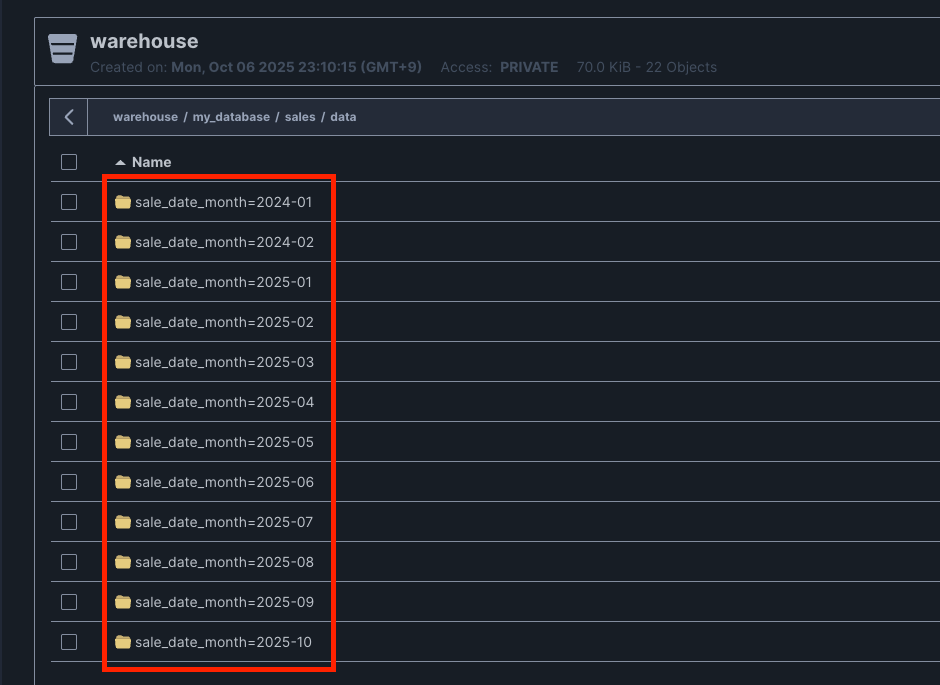

In [12]:
Image("/home/iceberg/notebooks/images/3_iceberg_hidden_partition.png")

---

# Partition pruning 확인해보기
- 히든 파티션 컬럼을 이용하여 쿼리 하였을 때 파티션 프루닝이 잘 진행 되는지 확인해보자.
- 파티션 키와 상관 없는 컬럼을 필터링 했을 때 파티션 프루닝이 안 되는지 확인해보자.
- item 컬럼을 필터링 했을 때 `spark-iceberg` 컨테이너에 쌓이는 spark events(history) 로그를 살펴보자.<br>(spark-history-server 를 따로 설정하지 않아서, 로그 파일을 직접 보겠다.)
- 로그는 `/home/iceberg/spark-events` 경로에 쌓이고 있다.

## 파티션 키가 아닌 컬럼으로 쿼리 했을 때

In [9]:
spark.sql("""
SELECT *
FROM my_catalog.my_database.sales
WHERE id = 10;
""").show(truncate=False)

+---+----+--------+----------+
|id |item|category|sale_date |
+---+----+--------+----------+
|10 |DVD |Media   |2025-07-30|
+---+----+--------+----------+



- `{"name":"total data manifests","accumulatorId":29,"metricType":"...TotalDataManifests"}`
- `{"name":"number of scanned data manifests","accumulatorId":30,"metricType":"...ScannedDataManifests"}`
- `{"name":"number of skipped data manifests","accumulatorId":31,"metricType":"....SkippedDataManifests"}`
- `{"Event":"org.apache.spark.sql.execution.ui.SparkListenerDriverAccumUpdates","executionId":2,"accumUpdates":[[28,517],[29,3],[30,3],[31,0],[32,5],[33,12],[34,6441],[35,0],[36,0],[37,0],[38,0],[39,0],[40,0],[41,0],[42,0],[43,0]]}`

### 로그 분석
- total data manifests 의 accumulatorId 는 29이다. 그리고 accumUpdates 에서 [29,3] 라고 되어 있으므로 총 데이터 매니패스트는 3개이다.
- scanned data manifests 의 accumulatorId 는 30이다. 그리고 accumUpdates 에서 [30,3] 라고 되어 있으므로 스캔한 데이터 매니패스트의 개수는 3개이다.
- skipped data manifests 의 accumulatorId 는 31이다. 그리고 accumUpdates 에서 [31,0] 라고 되어 있으므로 스킵한 데이터 매니페스트의 개수는 0개이다.
- **따라서, `WHERE item = 'DVD'`와 같이 파티션 키가 아닌 필드를 필터링 하였을 때 풀스캔이 발생한다.**

### Spark History Server 메트릭 확인
- 노트북을 여러번 실행해서 위 매트릭과 매니패스트 수가 동일하지 않을 수 있다. skipped 여부만 확인하자.


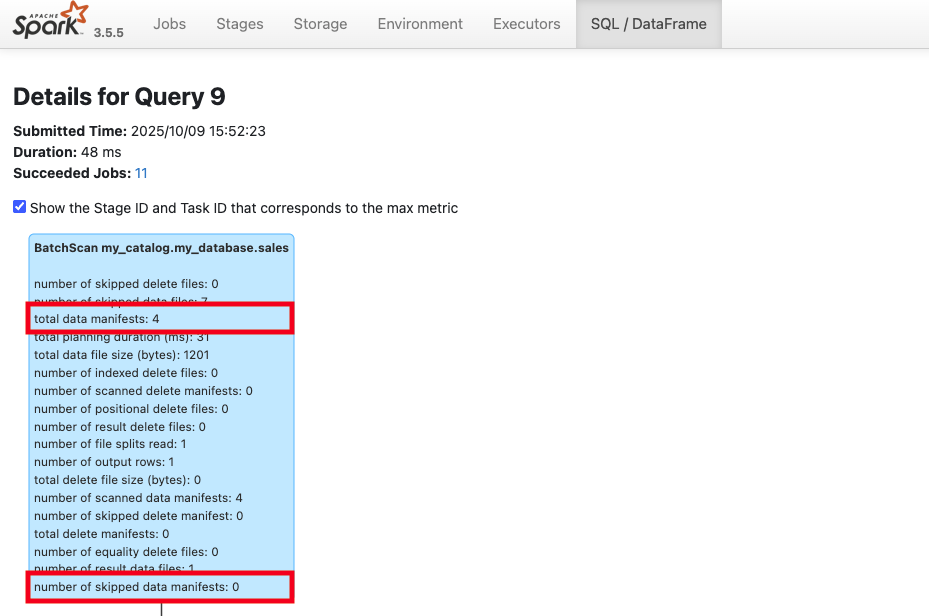

In [11]:
Image("/home/iceberg/notebooks/images/3_iceberg_hidden_partition_no_skipped.png")

## 히든 파티션 키로 지정한 컬럼으로 쿼리 했을 때

In [8]:
spark.sql("SELECT * FROM my_catalog.my_database.sales WHERE sale_date = '2024-01-15'").show()

+---+------+-----------+----------+
| id|  item|   category| sale_date|
+---+------+-----------+----------+
|  1|Laptop|Electronics|2024-01-15|
+---+------+-----------+----------+



- `{"name":"total data manifests","accumulatorId":29,"metricType":"...TotalDataManifests"}`
- `{"name":"number of scanned data manifests","accumulatorId":30,"metricType":"...ScannedDataManifests"}`
- `{"name":"number of skipped data manifests","accumulatorId":31,"metricType":"....SkippedDataManifests"}`
- `{"Event":"org.apache.spark.sql.execution.ui.SparkListenerDriverAccumUpdates","executionId":0,"accumUpdates":[[28,602],[29,3],[30,1],[31,2],[32,1],[33,1],[34,1247],[35,0],[36,0],[37,0],[38,0],[39,0],[40,0],[41,0],[42,0],[43,0]]}`

### 로그 분석
- total data manifests 의 accumulatorId 는 29이다. 그리고 accumUpdates 에서 [29,3] 라고 되어 있으므로 총 데이터 매니패스트는 3개이다.
- scanned data manifests 의 accumulatorId 는 30이다. 그리고 accumUpdates 에서 [30,1] 라고 되어 있으므로 스캔한 데이터 매니패스트의 개수는 1개이다.
- skipped data manifests 의 accumulatorId 는 31이다. 그리고 accumUpdates 에서 [31,2] 라고 되어 있으므로 **스킵한 데이터 매니페스트의 개수는 2개**이다.
- **따라서, `sale_date = '2024-01-15'`와 같이 필터링 했을 때 내부적으로 sale_date_month 키로 파티션 프루닝이 잘 동작한 것을 알 수 있다.**

### Spark History Server 메트릭 확인
- 노트북을 여러번 실행해서 위 매트릭과 매니패스트 수가 동일하지 않을 수 있다. skipped 여부만 확인하자.


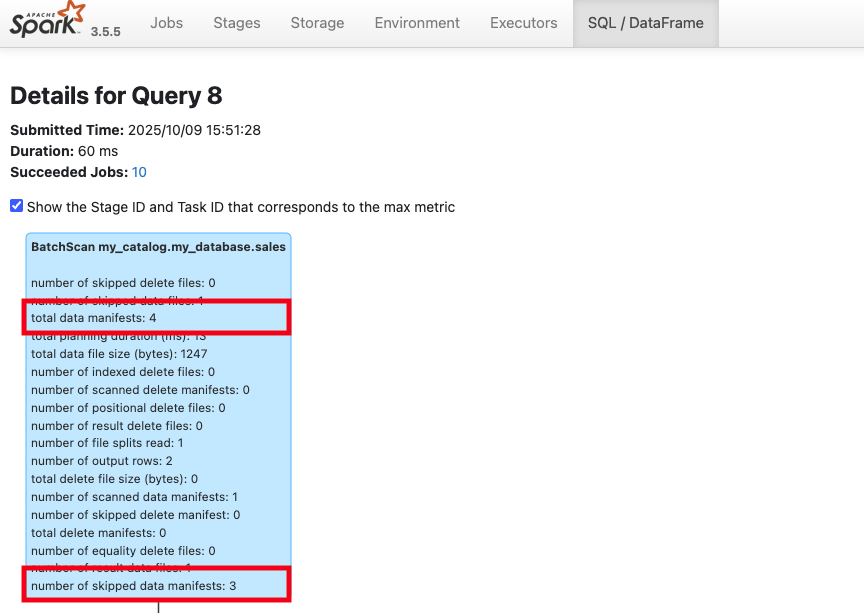

In [12]:
Image("/home/iceberg/notebooks/images/3_iceberg_hidden_partition_skipped.png")

## 메타데이터의 파티션 속성 확인해보기

In [12]:
! curl -s http://iceberg-rest:8181/v1/namespaces/my_database/tables/sales

{"metadata-location":"s3://warehouse/my_database/sales/metadata/00001-7868bd26-501f-48a1-a92d-ed1002ddb5aa.metadata.json","metadata":{"format-version":2,"table-uuid":"25902c75-d099-4464-810b-708c33967cff","location":"s3://warehouse/my_database/sales","last-sequence-number":1,"last-updated-ms":1760023827966,"last-column-id":4,"current-schema-id":0,"schemas":[{"type":"struct","schema-id":0,"fields":[{"id":1,"name":"id","required":false,"type":"long"},{"id":2,"name":"item","required":false,"type":"string"},{"id":3,"name":"category","required":false,"type":"string"},{"id":4,"name":"sale_date","required":false,"type":"date"}]}],"default-spec-id":0,"partition-specs":[{"spec-id":0,"fields":[{"name":"sale_date_month","transform":"month","source-id":4,"field-id":1000}]}],"last-partition-id":1000,"default-sort-order-id":0,"sort-orders":[{"order-id":0,"fields":[]}],"properties":{"owner":"root","write.parquet.compression-codec":"zstd"},"current-snapshot-id":5085095869947353656,"refs":{"main":{"sna

In [13]:
metadata_json = "00001-7868bd26-501f-48a1-a92d-ed1002ddb5aa.metadata.json"
obj = get_metadata(metadata_json, table='sales')
metadata_json = json.loads(obj["Body"].read().decode("utf-8"))

for key in IcebergMetadataJsonField:
    print(f"🔑'KEY':{key.value}({FIELD_DESCRIPTIONS[key]})\n ▶︎'VALUE':{metadata_json[key.value]}")
    print("-"*100)

print("\n📋 메타데이터 원본 JSON")
print(json.dumps(metadata_json, indent=2, ensure_ascii=False))

🔑'KEY':format-version(Iceberg 테이블 포맷 버전(https://iceberg.apache.org/spec/))
 ▶︎'VALUE':2
----------------------------------------------------------------------------------------------------
🔑'KEY':table-uuid(테이블을 고유하게 식별하는 UUID(테이블 변경, 데이터 갱신에도 변경되지 않는 정보))
 ▶︎'VALUE':25902c75-d099-4464-810b-708c33967cff
----------------------------------------------------------------------------------------------------
🔑'KEY':location(테이블 데이터와 메타데이터가 저장되는 경로)
 ▶︎'VALUE':s3://warehouse/my_database/sales
----------------------------------------------------------------------------------------------------
🔑'KEY':last-sequence-number(마지막으로 커밋된 작업의 시퀀스 번호 (트랜잭션 순서, 테이블 또는 데이터 갱신 작업마다 늘어남))
 ▶︎'VALUE':1
----------------------------------------------------------------------------------------------------
🔑'KEY':last-updated-ms(메타데이터가 마지막으로 갱신된 시각 (epoch 밀리초))
 ▶︎'VALUE':1760023827966
----------------------------------------------------------------------------------------------------
🔑'KEY':last-column-id(테이블에서 

---

# ALTER ADD PARTITION
- Iceberg 테이블은 ALTER 쿼리를 이용해 파티션 수정이 가능하다.
- 아래와 같이 **ADD PARTITION 으로 파티션 컬럼을 추가하면 파티션을 추가한 이후 갱신된 데이터만 영향을 받는다.**
- 그래서 파티션 변경에 유연하게 대응 될 수 있는 것이다.
- 만약 ADD PARTITION 후 모든 데이터 파일에 파티션을 적용하려면 Iceberg 시스템 프로시저 중 **rewrite** 를 이용해야한다.

In [14]:
spark.sql("""
ALTER TABLE my_catalog.my_database.sales
ADD PARTITION FIELD category
""")

DataFrame[]

In [15]:
spark.sql("""
INSERT INTO my_catalog.my_database.sales VALUES
    (31, 'Dress',       'Clothing',    DATE '2024-06-05'),
    (32, 'Jacket',      'Clothing',    DATE '2024-06-21')
""")

DataFrame[]

- 아래 이미지와 같이 `sale_date_month` 가 `2024-06` 인 파티션 하위에 `category` 파티션이 추가되었다.
- 아직 나머지 `sale_date_month` 파티션에는 `category` 파티션이 없는 상태이다.
- ADD PARTITION 이후에 갱신된 데이터만 영향을 받기 때문이다.

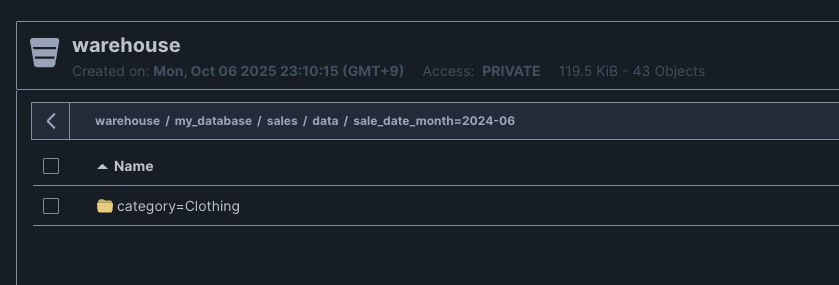

In [20]:
Image("/home/iceberg/notebooks/images/3_iceberg_add_partition.png")

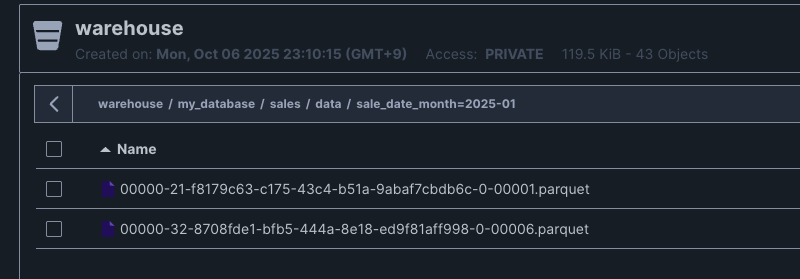

In [21]:
Image("/home/iceberg/notebooks/images/3_iceberg_add_partition_2.png")

## [REWRITE DATA FILES](https://iceberg.apache.org/docs/nightly/spark-procedures/?h=remove#rewrite_data_files)(Iceberg procedure)
- ADD PARTITION 후 전체 데이터 파일에 대해서 추가된 파티션을 적용 시키기 위해 Spark Iceberg procedure 인 `rewrite_data_files`를 사용할 수 있다.
- rewrite_data_files 는 데이터 파일을 다시 쓰면서 재배치하는 프로시져이다.

In [16]:
spark.sql("""
CALL my_catalog.system.rewrite_data_files(
  table => 'my_catalog.my_database.sales',
  strategy => 'binpack',
  options => map(
    'rewrite-all', 'true',
    'target-file-size-bytes','536870912'
  )
)
""")

DataFrame[rewritten_data_files_count: int, added_data_files_count: int, rewritten_bytes_count: bigint, failed_data_files_count: int]

- `rewrite_data_file` 후에 데이터 파일을 살펴보면 아래 이미지와 같이 기존에 `sale_date_month` 파티션만 존재하던 경로도 `category` 파티션이 추가 되면서 2개였던 parquet 파일이 하나의 parquet 파일로 병합되어 데이터 파일이 재배치 된 걸 알 수 있다.

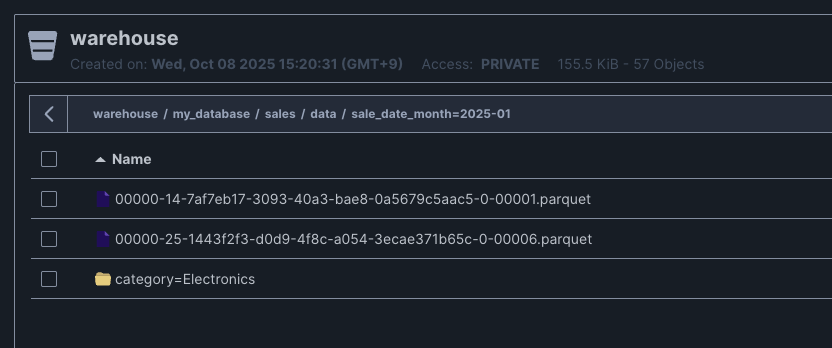

In [47]:
Image("/home/iceberg/notebooks/images/3_iceberg_rewrite_data_file.png")

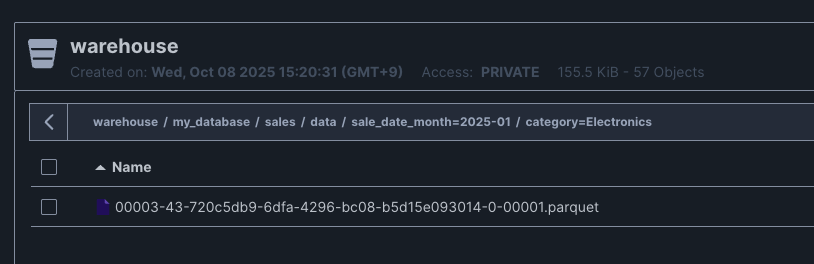

In [45]:
Image("/home/iceberg/notebooks/images/3_iceberg_rewrite_data_file_2.png")

- category 파티션이 추가 되면서 데이터 파일이 재배치 되었지만, 기존에 있던 parquet 파일이 그대로 있다. 
- 아래 쿼리를 통해 실제로 각 행이 어떤 데이터 파일에서 조회된 것인지 확인해보자.

In [19]:
df = spark.sql("""
SELECT id, item, category, sale_date
FROM my_catalog.my_database.sales
WHERE sale_date BETWEEN '2024-01-01' AND '2024-01-30'
""").withColumn("file_path", input_file_name())

df.show(truncate=False)

+---+------+-----------+----------+------------------------------------------------------------------------------------------------------------------------------------------------+
|id |item  |category   |sale_date |file_path                                                                                                                                       |
+---+------+-----------+----------+------------------------------------------------------------------------------------------------------------------------------------------------+
|3  |Shirt |Clothing   |2024-01-20|s3://warehouse/my_database/sales/data/sale_date_month=2024-01/category=Clothing/00000-21-3d45958a-5e92-4494-a4e0-673df0f756f3-0-00001.parquet   |
|1  |Laptop|Electronics|2024-01-15|s3://warehouse/my_database/sales/data/sale_date_month=2024-01/category=Electronics/00001-22-3d45958a-5e92-4494-a4e0-673df0f756f3-0-00001.parquet|
+---+------+-----------+----------+------------------------------------------------------------

- 위 쿼리 결과와 같이 sales 테이블의 최신 매니패스트는 `rewrite_data_file` 이후 새로 생성된 parquet 파일을 추적하고 있다.